<a href="https://colab.research.google.com/github/Miller12567/5201_Intro_to_Siesmology/blob/main/5201_HW_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Introduction to Seismology

Earth 5201

Homework 1

Due Friday September 25, 2026

Evan Miller

**1) Describe the differences between source, path, and site terms? What are common examples for each of these terms? Explain how certain site terms will alter your observed ground motions.**

Source: The source is where a(n) event(s) that causes seismic waves occurs.

Path: The path is the curve or line that goes from the source to the site and what dictates why they travel the way they do.

Site Terms: Site terms are how an areas physical properties are described.

Some common examples for sources are, fault slipping events, explosives (dynamite or nuclear tests), or even walking are sources of siesmic waves.

An example for paths are, how siesmic waves will travel through layers of the earth in a curve, and some more linearly through the crust, and may even arrive at the same location.

A Site Term example could be, "A" which descibes an velocity of shear waves as that of traveling through hard rock.

Certin cite terms, like "B" or "C" which describe the physical makeup of a site will effect your predicted measurements i.e. attributing a site as "A" (hard rock) when in reality it is clay or whatever, will cause big problems when making predictions.

**2) Find a vertical component velocity seismometer in an urban area versus a rural area.
Compute and plot the probabilistic power spectrum for a day of data. Label the
microseism band on the plots. Which of the two stations has less noise and why?**


In [1]:
%pip install obspy -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 35.8 MB/s eta 0:00:00


Inventory created at 2026-10-09T04:07:27.939800Z
	Created by: EarthScope WEB SERVICE: fdsnws-station | version: 1.1.58
		    https://service.earthscope.org/fdsnws/station/1/query?starttime=202...
	Sending institution: EarthScope (EarthScope)
	Contains:
		Networks (1):
			LD
		Stations (1):
			LD.CPNY (Central Park, New York City)
		Channels (1):
			LD.CPNY..HHZ


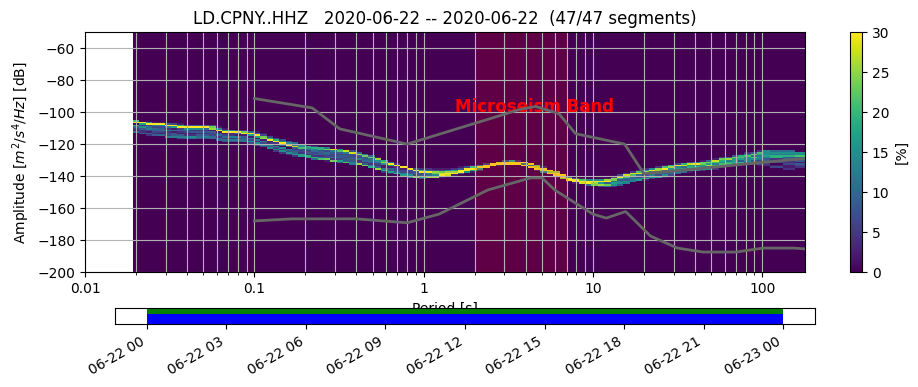

Inventory created at 2026-10-09T04:07:36.700800Z
	Created by: EarthScope WEB SERVICE: fdsnws-station | version: 1.1.58
		    https://service.earthscope.org/fdsnws/station/1/query?starttime=202...
	Sending institution: EarthScope (EarthScope)
	Contains:
		Networks (1):
			OH
		Stations (1):
			OH.SROH (Shade River State Forest)
		Channels (1):
			OH.SROH..HHZ


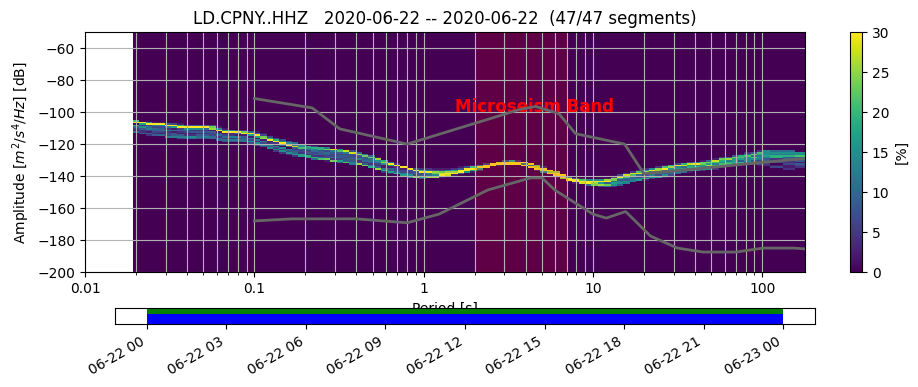

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import obspy
from obspy.clients.fdsn import Client
from obspy.geodetics.base import gps2dist_azimuth, kilometer2degrees
import matplotlib.pyplot as plt

from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from obspy import read, read_inventory
from obspy.io.xseed import Parser
from obspy.signal import PPSD

plt.rcParams["figure.figsize"] = (10, 4)
client = Client("EARTHSCOPE")
#print(client)


# Urban - Manhatten NYC

inventoryNYC = client.get_stations(
    network="LD",
    station="CPNY",
    channel="HHZ",
    level="channel",
    starttime=UTCDateTime("2020-06-22"),
    endtime=UTCDateTime("2020-06-23"),
)
print(inventoryNYC)


stNYC = client.get_waveforms(
  network="LD",
  station="CPNY",
  channel="HHZ",
  location="",
  starttime=UTCDateTime("2020-06-22"),
  endtime=UTCDateTime("2020-06-23"))

inv = client.get_stations(network="LD", station="CPNY", location="",
                          channel="HHZ", level="response")

ppsd = PPSD(stNYC[0].stats, metadata=inv)
ppsd.add(stNYC)

figNYC = ppsd.plot(show=False) # Plot without showing it yet
axNYC = figNYC.axes[0]



axNYC.axvspan(2, 7, color='red', alpha=0.15, label='Highlighted Band')

# Place text near the highlighted region
# Arguments: x-coordinate, y-coordinate, "your text label"
# 'horizontalalignment' helps center the text on the x-coordinate
axNYC.text(4.5, -100, "Microseism Band", color='red', fontsize=12, fontweight='bold', ha='center')

plt.show()

################################################################################
# Rural - Rural OH

Rural_network = "OH"
Rural_station = "SROH"


inventoryOH = client.get_stations(
    network=Rural_network,
    station=Rural_station,
    channel="HHZ",
    level="channel",
    starttime=UTCDateTime("2020-06-22"),
    endtime=UTCDateTime("2020-06-23"),
)
print(inventoryOH)


stOH = client.get_waveforms(
  network=Rural_network,
  station=Rural_station,
  channel="HHZ",
  location="",
  starttime=UTCDateTime("2020-06-22"),
  endtime=UTCDateTime("2020-06-23")
  )

inv2 = client.get_stations(
  network=Rural_network,
  station=Rural_station,
  location="",
  channel="HHZ",
  level="response"
  )

ppsd2 = PPSD(stOH[0].stats, metadata=inv2)
ppsd2.add(stOH)

figOH = ppsd.plot(show=False) # Plot without showing it yet
axOH = figOH.axes[0]



axOH.axvspan(2, 7, color='red', alpha=0.15, label='Highlighted Band')

# Place text near the highlighted region
# Arguments: x-coordinate, y-coordinate, "your text label"
# 'horizontalalignment' helps center the text on the x-coordinate
axOH.text(4.5, -100, "Microseism Band", color='red', fontsize=12, fontweight='bold', ha='center')

plt.show()

The rural area has less noise, which is due to its farther distance from a ocean and less human activity, which are sources of noise (cars, footsteps, other human activity & waves crashing for the ocean (maybe Lake Erie can cause some but I don't know by how much)).

**3a) The Sumatra region of Indonesia has experienced 10 M7.5+ earthquakes since 2000.**

**For 4 of the earthquakes, plot the vertical component velocity seismograms (either BHZ or HHZ) at the same station for 1 hour after the origin time.**

**Comment on apparent differences between the seismograms. From the apparent P-wave arrivals, make an estimate of the average P-wave velocity.**

**Next, plot the power spectral densities of these waveforms and comment on any differences you see. Use the USGS earthquake catalog to find information about these earthquakes (https://earthquake.usgs.gov/earthquakes/map)**

Event:	2010-10-25T14:42:22.460000Z |  -3.487, +100.082 | 7.8  mwc | manual

	            resource_id: ResourceIdentifier(id="quakeml:earthquake.usgs.gov/fdsnws/event/1/query?eventid=usp000hnj4&format=quakeml")
	             event_type: 'earthquake'
	          creation_info: CreationInfo(agency_id='us', creation_time=UTCDateTime(2022, 7, 18, 22, 57, 12, 869000))
	    preferred_origin_id: ResourceIdentifier(id="quakeml:earthquake.usgs.gov/product/origin/usp000hnj4/us/1415324565466")
	 preferred_magnitude_id: ResourceIdentifier(id="quakeml:earthquake.usgs.gov/product/origin/usp000hnj4/us/1415324565466#magnitude")
	                   ---------
	     event_descriptions: 1 Elements
	                origins: 1 Elements
	             magnitudes: 1 Elements


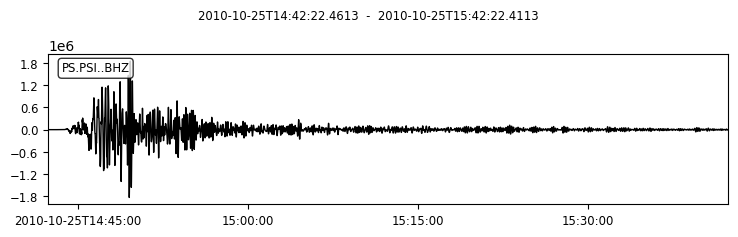

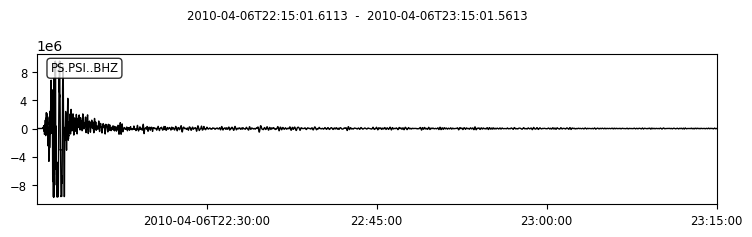

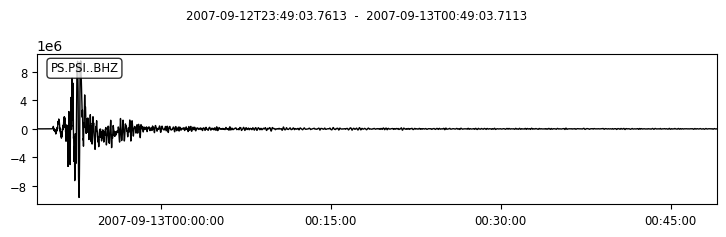

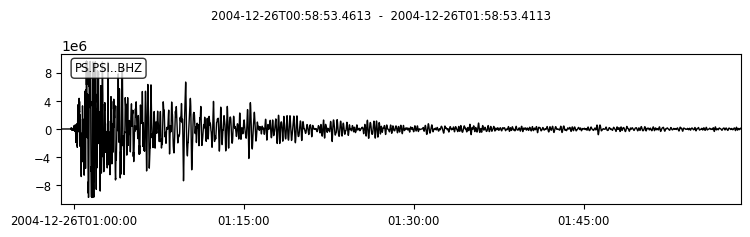

In [3]:
client_events = Client("USGS")
client2 = Client("GEOFON")
client3 = Client("EARTHSCOPE")
events = client_events.get_events(
    starttime=UTCDateTime("2000-01-01"),
    endtime=UTCDateTime("2026-06-30"),
    latitude=-0.2,
  longitude=101.2, # – Specify the longitude to be used for a radius search.
  minradius=0, # – Limit to events within the specified minimum number of degrees from the geographic point defined by the latitude and longitude parameters.
  maxradius=8, # – Limit to events within the specified maximum number of degrees from the geographic point defined by the latitude and longitude parameters.
    minmagnitude=7.5,
    maxmagnitude=10.0,
)
print(events[0])

EQ1S = events[0].origins[0].time
EQ1E = EQ1S + 3600

EQ2S = events[1].origins[0].time
EQ2E = EQ2S + 3600

EQ3S = events[3].origins[0].time
EQ3E = EQ3S + 3600

EQ4S = events[6].origins[0].time
EQ4E = EQ4S + 3600

Q3_statiosn = client2.get_stations(
  starttime=UTCDateTime("2000-01-01"),
  endtime=UTCDateTime("2026-06-30"),
  latitude=-0.2,
  longitude=101.2, # – Specify the longitude to be used for a radius search.
  minradius=0, # – Limit to events within the specified minimum number of degrees from the geographic point defined by the latitude and longitude parameters.
  maxradius=10
  )


####################################################################
st1 = client3.get_waveforms(
    network="PS", station="PSI", location="", channel="BHZ",
    starttime=EQ1S, endtime=EQ1E,
)
st1.plot();

####################################################################
st2 = client3.get_waveforms(
    network="PS", station="PSI", location="", channel="BHZ",
    starttime=EQ2S, endtime=EQ2E,
)
st2.plot();

####################################################################
st3 = client3.get_waveforms(
    network="PS", station="PSI", location="", channel="BHZ",
    starttime=EQ3S, endtime=EQ3E,
)
st3.plot();

####################################################################
st4 = client3.get_waveforms(
    network="PS", station="PSI", location="", channel="BHZ",
    starttime=EQ4S, endtime=EQ4E,
)
st4.plot();

####################################################################



The differences between the events can be noticed in the time of arrival. It makes sense as these events occured at varying distances from the seismometer. Also apparent is the highest amplitudes of the seismographs which shows the amount of shaking at the seismometer.


In [4]:
import math
p_arrival = np.array([ UTCDateTime("2010-10-25T14:43:45") , UTCDateTime("2010-04-06T22:15:30") , UTCDateTime("2007-09-12T23:50:30") , UTCDateTime("2004-12-26T01:00:00") ]) #times

depth_km = np.array([ 21.1 , 31.0 , 35.0 , 30.0 ]) #distances gotten from google

epi_km = np.array([ 698, 212 , 627 , 740 ]) #distances gotten from google

hyppo_km = np.array([math.sqrt((depth_km[0])**2 + (epi_km[0])**2), math.sqrt((depth_km[1])**2 + (epi_km[1])**2) ,math.sqrt((depth_km[2])**2 + (epi_km[2])**2), math.sqrt((depth_km[3])**2 + (epi_km[3])**2)])
origin = np.array([ events[0].origins[0].time, events[1].origins[0].time, events[3].origins[0].time, events[6].origins[0].time])

time = p_arrival - origin

velocity = hyppo_km / time

print("the velocities are:", velocity, "km/s")

the velocities are: [8.460368857693188 7.53886423431456 7.27835088311818 11.128592914371465] km/s


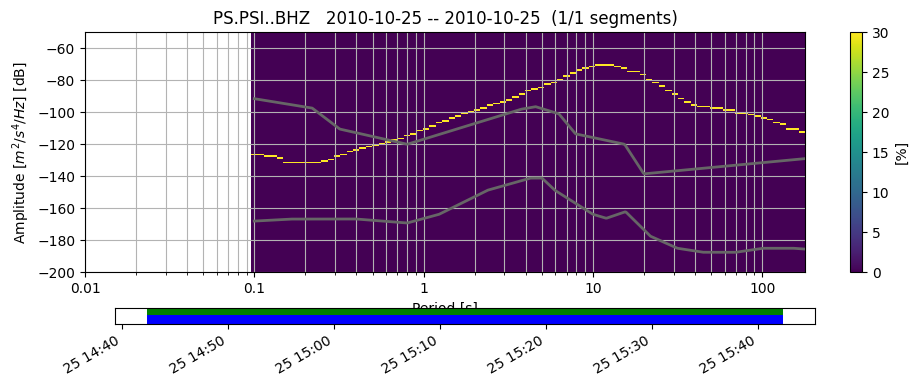

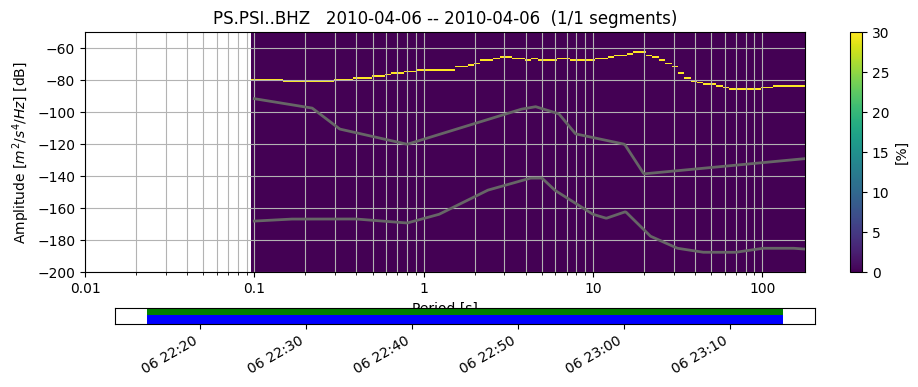

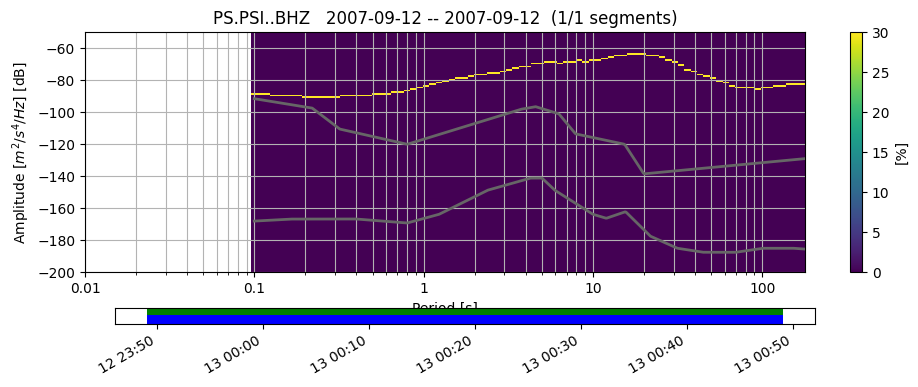

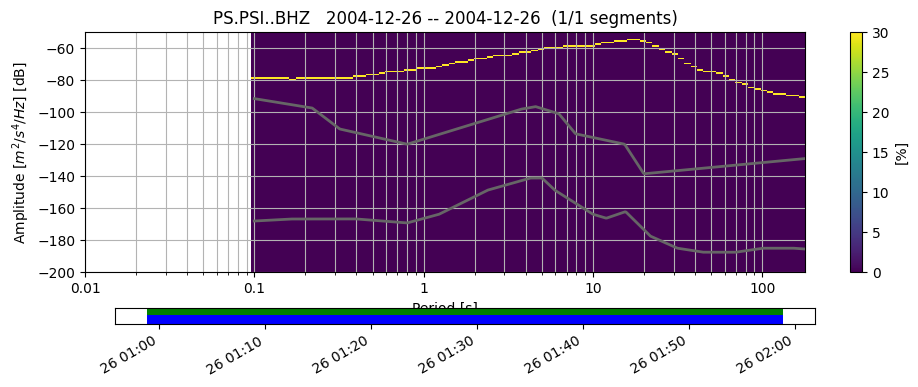

In [5]:
inv_psi = client3.get_stations(
    network="PS",
    station="PSI",
    location="",
    channel="BHZ",
    level="response",
    starttime=UTCDateTime("2004-01-01"),
    endtime=UTCDateTime("2011-01-01")
)

ppsd1 = PPSD(st1[0].stats, metadata=inv_psi)
ppsd1.add(st1)
fig_psd1 = ppsd1.plot(show=False)
plt.show()

ppsd2 = PPSD(st2[0].stats, metadata=inv_psi)
ppsd2.add(st2)
fig_psd2 = ppsd2.plot(show=False)
plt.show()

ppsd3 = PPSD(st3[0].stats, metadata=inv_psi)
ppsd3.add(st3)
fig_psd3 = ppsd3.plot(show=False)
plt.show()

ppsd4 = PPSD(st4[0].stats, metadata=inv_psi)
ppsd4.add(st4)
fig_psd4 = ppsd4.plot(show=False)
plt.show()

They all seem to be above mean readings, which is good because these are all MASSIVE events compared to the normal seismic activity for a day.

**3b) For one of the Sumatra earthquakes, find vertical component velocity seismograms for 4 different stations at different source distances and plot them as a function of distance from the source in degrees.**

**Make an estimate of the average velocity here based on the P wave arrivals.**

{'origin_time': UTCDateTime(2004, 12, 26, 0, 58, 53), 'latitude': 3.316, 'longitude': 95.854, 'magnitude': 9.1, 'description': '2004 Sumatra-Andaman Earthquake'}
[49.42388839139873]


/tmp/ipykernel_3619/2159728733.py:39: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  st = client.get_waveforms(


[49.42388839139873, 41.20828133334574]


/tmp/ipykernel_3619/2159728733.py:39: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  st = client.get_waveforms(


[49.42388839139873, 41.20828133334574, 97.81401738779111]


/tmp/ipykernel_3619/2159728733.py:39: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  st = client.get_waveforms(


[49.42388839139873, 41.20828133334574, 97.81401738779111, 136.4781497424089]


/tmp/ipykernel_3619/2159728733.py:39: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  st = client.get_waveforms(


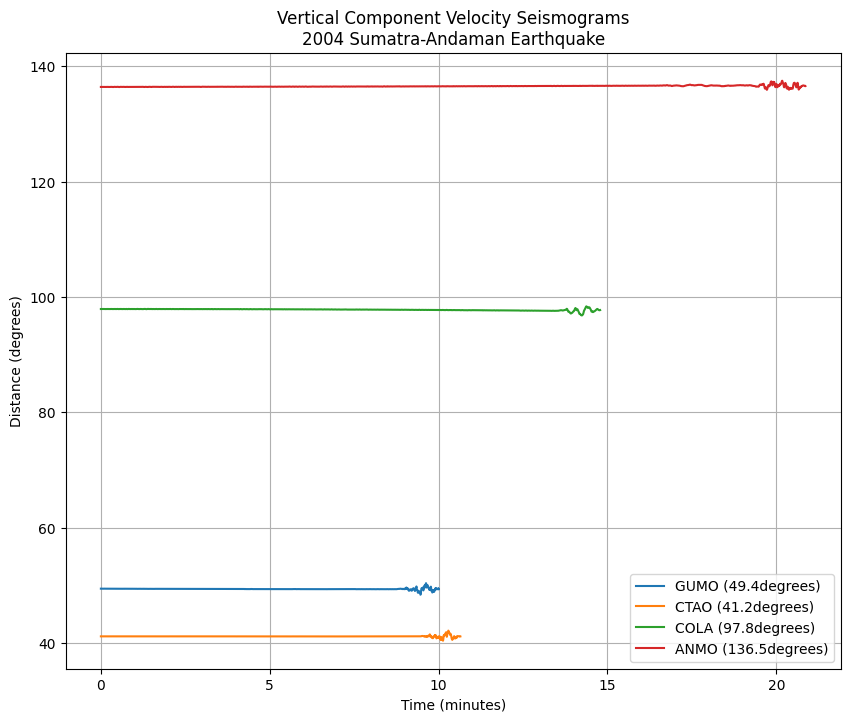

Average P-wave Velocity: 5.62 km/s


In [6]:
# Initialize IRIS client
client = Client("EARTHSCOPE")

# Define the earthquake
earthquake = {
    "origin_time": obspy.UTCDateTime("2004-12-26T00:58:53"),
    "latitude": 3.316,
    "longitude": 95.854,
    "magnitude": 9.1,
    "description": "2004 Sumatra-Andaman Earthquake",
}
print(earthquake)

# List of stations
stations = [
    {"network": "IU", "station": "GUMO", "latitude": 13.436, "longitude": 144.808},
    {"network": "IU", "station": "CTAO", "latitude": -19.443, "longitude": 130.846},
    {"network": "IU", "station": "COLA", "latitude": 64.869, "longitude": -147.860},
    {"network": "IU", "station": "ANMO", "latitude": 34.946, "longitude": -106.456},
]

# Fetch waveforms and calculate distances
traces = []
distances = []

for station in stations:
    try:
        # Calculate the distance in degrees
        dist_m, _, _ = gps2dist_azimuth(
            earthquake["latitude"],
            earthquake["longitude"],
            station["latitude"],
            station["longitude"],
        )
        dist_deg = kilometer2degrees(dist_m / 1000.0)
        distances.append(dist_deg)
        print(distances)
        # Fetch waveform data
        st = client.get_waveforms(
            network=station["network"],
            station=station["station"],
            location="00",
            channel="BHZ",
            starttime=earthquake["origin_time"],
            endtime=earthquake["origin_time"] + 3600,
            attach_response=True,
        )

        # Remove instrument response to get velocity
        st.remove_response(output="VEL")
        traces.append((station["station"], st[0]))
    except Exception as e:
        print(f"Failed to fetch data for station {station['station']}: {e}")
# Plot seismograms as a function of distance
plt.figure(figsize=(10, 8))
for station, tr in traces:
    plt.plot(
        tr.times() / 60,  # Convert time to minutes
        tr.data / max(abs(tr.data)) + distances[traces.index((station, tr))],
        label=f"{station} ({distances[traces.index((station, tr))]:.1f}degrees)",
    )

plt.xlabel("Time (minutes)")
plt.ylabel("Distance (degrees)")
plt.title(f"Vertical Component Velocity Seismograms\n{earthquake['description']}")
plt.legend()
plt.grid()
plt.show()

# Average P-wave velocity
p_wave_times = [28*60, 25*60, 35*60, 23*60]
p_wave_distances = distances  # Distances in degrees
p_wave_velocities = [
    d * 111 / t for d, t in zip(p_wave_distances, p_wave_times)
]

average_velocity = sum(p_wave_velocities) / len(p_wave_velocities)
print(f"Average P-wave Velocity: {average_velocity:.2f} km/s")



**3c) For one of your waveforms, apply a high-pass filter at 0.01 and 1 Hz and plot the results. Label any phase arrivals that you may see.**

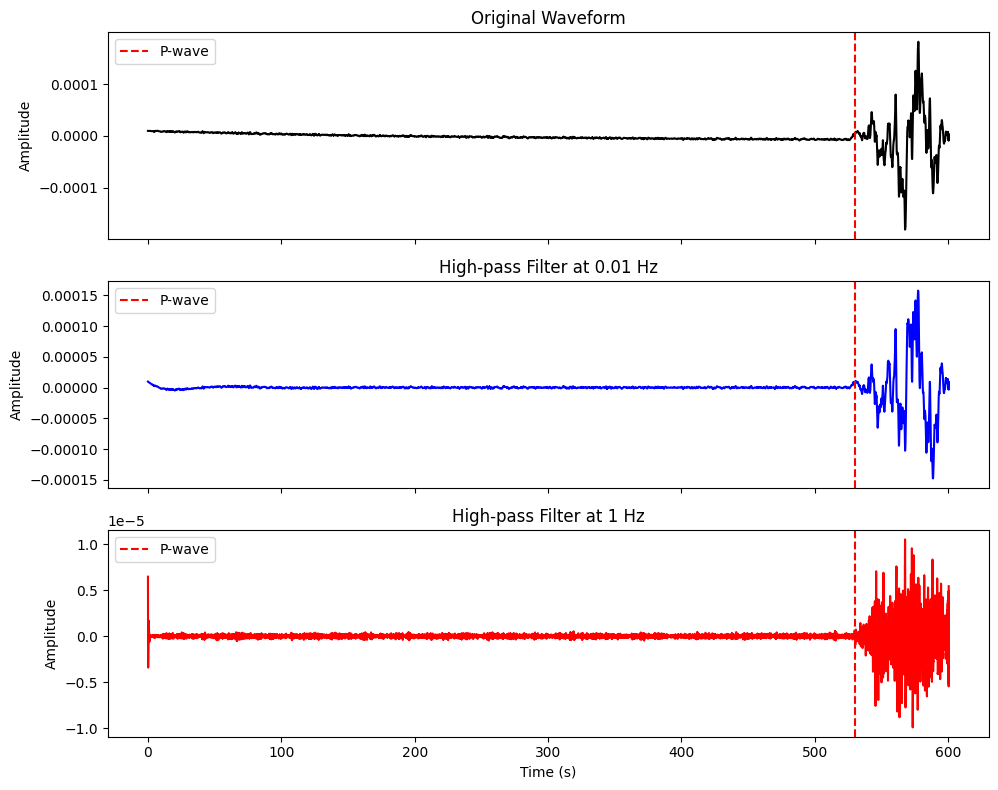

In [7]:
selected_station = "GUMO"
tr = None
for station, trace in traces:
    if station == selected_station:
        tr = trace
        break

if tr is None:
    print(f"Waveform for station {selected_station} not found.")
else:

    tr_original = tr.copy()  # Original waveform
    tr_hp_0_01 = tr.copy().filter("highpass", freq=0.01)  # High-pass at 0.01 Hz
    tr_hp_1 = tr.copy().filter("highpass", freq=1.0)  # High-pass at 1 Hz


    # Plot the results
    fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    # Original waveform
    axs[0].plot(tr_original.times(), tr_original.data, color="black")
    axs[0].axvline(530, color="red", linestyle="--", label="P-wave")
    axs[0].set_title("Original Waveform")
    axs[0].set_ylabel("Amplitude")
    axs[0].legend()

    # High-pass filter at 0.01 Hz
    axs[1].plot(tr_hp_0_01.times(), tr_hp_0_01.data, color="blue")
    axs[1].axvline(530, color="red", linestyle="--", label="P-wave")
    axs[1].set_title("High-pass Filter at 0.01 Hz")
    axs[1].set_ylabel("Amplitude")
    axs[1].legend()

    # High-pass filter at 1 Hz
    axs[2].plot(tr_hp_1.times(), tr_hp_1.data, color="red")
    axs[2].axvline(530, color="red", linestyle="--", label="P-wave")
    axs[2].set_title("High-pass Filter at 1 Hz")
    axs[2].set_xlabel("Time (s)")
    axs[2].set_ylabel("Amplitude")
    axs[2].legend()

    # Finalize the plot
    plt.tight_layout()
    plt.show()